# Tweets about the Top Companies from 2015 to 2020

This dataset, part of a paper published in the *2020 IEEE International Conference on Big Data* (under the 6th Special Session on Intelligent Data Mining track), was created to determine possible speculators and influencers in the stock market.

Although both tweet data and companies' market data were used in the project, the authors chose to split the datasets into two parts when sharing on Kaggle. This dataset is especially useful for analyzing tweets written about **Amazon, Apple, Google, Microsoft, and Tesla**, identified by their respective share tickers.

>  **Note**: If you're interested in evaluating speculators and influencers in a stock market, you may also find the following dataset useful:  
> [Values of Top Nasdaq Companies (2010–2020)](https://www.kaggle.com/omermetinn/values-of-top-nasdaq-copanies-from-2010-to-2020)

---

## Content

This dataset includes **over 3 million unique tweets**, each with:

- Tweet ID  
- Author (writer)  
- Post date  
- Text body  
- Number of comments  
- Number of likes  
- Number of retweets  
- Matched company information  

---

##  Acknowledgements

Tweets were collected from Twitter using a Selenium-based parsing script.

-  [Tweet Collector Script on GitHub](https://github.com/omer-metin/TweetCollector)  
-  [Published Paper on IEEE Xplore](https://ieeexplore.ieee.org/document/9378170)

---

##  Inspiration

Here are a few research directions and tasks that can be explored using this dataset:

1.  **Correlation Analysis**: Analyze the relationship between a company's market value and public sentiment over time.
2.  **Sentiment Time Series**: Perform sentiment analysis and plot time series to investigate rises and falls in public opinion.
3.  **Troll Detection**: Identify and analyze troll users aiming to influence social media trends or stock movements.


In [1]:
import pandas as pd
tweet_data = pd.read_csv("/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Dataset/raw/tweet_data_new/Tweet.csv", delimiter=",")

**Inspect the Data**

Check for issues like missing values or incorrectly formatted columns.

In [2]:
print(tweet_data.head())

             tweet_id           writer   post_date  \
0  550441509175443456  VisualStockRSRC  1420070457   
1  550441672312512512      KeralaGuy77  1420070496   
2  550441732014223360      DozenStocks  1420070510   
3  550442977802207232     ShowDreamCar  1420070807   
4  550443807834402816     i_Know_First  1420071005   

                                                body  comment_num  \
0  lx21 made $10,008  on $AAPL -Check it out! htt...            0   
1  Insanity of today weirdo massive selling. $aap...            0   
2  S&P100 #Stocks Performance $HD $LOW $SBUX $TGT...            0   
3  $GM $TSLA: Volkswagen Pushes 2014 Record Recal...            0   
4  Swing Trading: Up To 8.91% Return In 14 Days h...            0   

   retweet_num  like_num  
0            0         1  
1            0         0  
2            0         0  
3            0         1  
4            0         1  


In [3]:
print(tweet_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3717964 entries, 0 to 3717963
Data columns (total 7 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   tweet_id     int64 
 1   writer       object
 2   post_date    int64 
 3   body         object
 4   comment_num  int64 
 5   retweet_num  int64 
 6   like_num     int64 
dtypes: int64(5), object(2)
memory usage: 198.6+ MB
None


In [4]:
import datetime

# Apply the conversion to the 'post_date' column
tweet_data["post_date"] = tweet_data["post_date"].apply(
    lambda x: datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d %H:%M:%S')
)


/var/folders/qz/ctfh_y5s4f5g3k2h_nzprjm00000gn/T/ipykernel_33362/27240640.py:5: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  lambda x: datetime.datetime.utcfromtimestamp(x).strftime('%Y-%m-%d %H:%M:%S')


In [5]:
print(tweet_data.isnull().sum())

tweet_id           0
writer         47273
post_date          0
body               0
comment_num        0
retweet_num        0
like_num           0
dtype: int64


The dataset consists of 5,000 observations. Among these, 1,300 observations are labeled with sentiments as 'positive', 'negative', or 'neutral', while the remaining 3,700 observations are unlabeled, with their sentiment marked as `NaN`.

In [6]:
tweet_data = tweet_data.rename(columns={'tweet_id': 'tweet_id', 'post_date': 'created_at', 'body': 'text'})

**Clean the Text Data**

In [7]:
print(tweet_data['text'].head())

0    lx21 made $10,008  on $AAPL -Check it out! htt...
1    Insanity of today weirdo massive selling. $aap...
2    S&P100 #Stocks Performance $HD $LOW $SBUX $TGT...
3    $GM $TSLA: Volkswagen Pushes 2014 Record Recal...
4    Swing Trading: Up To 8.91% Return In 14 Days h...
Name: text, dtype: object



As observed, raw text data often contains noise and inconsistencies that can impede accurate sentiment analysis. To address this, preprocessing is an essential step to clean, standardize, and structure the data, ensuring its suitability for machine learning algorithms. The following steps are commonly employed to prepare textual data effectively:

*Lowercasing:* All text is converted to lowercase to ensure uniformity and avoid treating the same word differently due to capitalization (e.g., "Happy" vs. "happy").

*Removal of URLs:* Text often contains hyperlinks that do not contribute to the sentiment of the content. These are removed to reduce noise.

*Remove Mentions:* Mentions, typically denoted by the @ symbol followed by a username (e.g., @user), are common in social media text. While they indicate a reference to another user, they usually do not contribute to the sentiment of the text and are removed to reduce noise.

*Handling Hashtags:* Hashtags are common in social media text. While the # symbol is removed, the associated words are retained, as they may provide context or sentiment-related information.

*Removal of Numeric and Punctuation Data:* Numbers and punctuation marks, unless contextually relevant, are removed to simplify the text.

Perform text preprocessing to ensure consistency and remove noise.

In [8]:
import sys
sys.path.append('/Users/shokoufehnaseri/Documents/GitHub/RR_thesis/src')
from data import preprocess_tweet


In [9]:
tweet_data = preprocess_tweet.Preprocess_Tweets(tweet_data)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pandas/core/strings/object_array.py:172: FutureWarning: Possible nested set at position 1
  pat = re.compile(pat, flags=flags)


In [12]:
tweet_data.isnull().sum()

tweet_id            0
writer          47273
created_at          0
text                0
comment_num         0
retweet_num         0
like_num            0
Text_Cleaned        0
dtype: int64

In [10]:
tweet_data.head()

,tweet_id,writer,created_at,text,comment_num,retweet_num,like_num,Text_Cleaned
0,550441509175443456,VisualStockRSRC,2015-01-01 00:00:57,"lx21 made $10,008 on $AAPL -Check it out! htt...",0,0,1,lx made on aapl check it out httpprofitlymndsa...
1,550441672312512512,KeralaGuy77,2015-01-01 00:01:36,Insanity of today weirdo massive selling. $aap...,0,0,0,insanity of today weirdo massive selling aapl ...
2,550441732014223360,DozenStocks,2015-01-01 00:01:50,S&P100 #Stocks Performance $HD $LOW $SBUX $TGT...,0,0,0,sp stocks performance hd low sbux tgt dvn ibm ...
3,550442977802207232,ShowDreamCar,2015-01-01 00:06:47,$GM $TSLA: Volkswagen Pushes 2014 Record Recal...,0,0,1,gm tsla volkswagen pushes record recall tally ...
4,550443807834402816,i_Know_First,2015-01-01 00:10:05,Swing Trading: Up To 8.91% Return In 14 Days h...,0,0,1,swing trading up to return in days httpowlygdk...


### **Remove Stop Words**
Remove common words that don't contribute to sentiment.

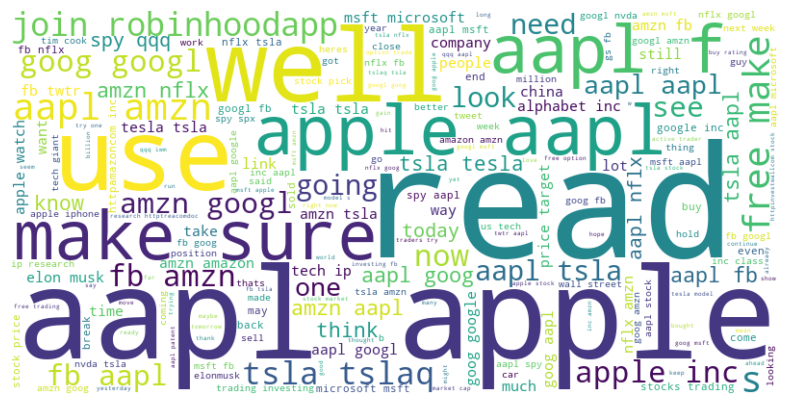

In [13]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert the Series to a single string
text_string = " ".join(tweet_data['Text_Cleaned'].dropna())  # Drop NaN values if any

# Generate the word cloud
wordcloud_before_stopword = WordCloud(width=800, height=400, background_color='white').generate(text_string)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_before_stopword, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.show()


In [14]:
import nltk
nltk.download('stopwords')
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# General English stop words
general_stop_words = set(ENGLISH_STOP_WORDS)

# Add custom ones from the word cloud
custom_stopwords = set([
    'read', 'use', 'make', 'sure', 'join', 'still', 'see', 'much', 'look', 'one', 'work',
    'now', 'time', 'know', 'get', 'take', 'back', 'free', 'today', 'need', 'well', 'way',
    'apple', 'aapl', 'amzn', 'tsla', 'goog', 'googl', 'fb', 'nflx', 'spy', 'msft',
    'apple inc', 'amazon', 'amazon.com', 'tesla', 'elonmusk', 'microsoft', 'alphabet inc', 'google inc'
])

# Combine both
all_stopwords = general_stop_words.union(custom_stopwords)

# Remove stopwords function
def remove_stopwords(text, stopwords):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stopwords]
    return " ".join(filtered_words)

# Apply the function to the 'text' column
tweet_data['Text_Cleaned'] = tweet_data['Text_Cleaned'].apply(lambda x: remove_stopwords(x, all_stopwords))


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/shokoufehnaseri/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


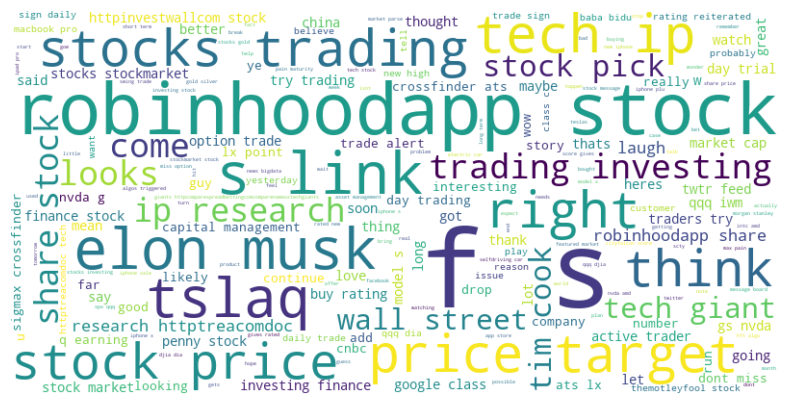

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert the Series to a single string
text_string = " ".join(tweet_data['Text_Cleaned'].dropna())  # Drop NaN values if any

# Generate the word cloud
wordcloud_after_stopword = WordCloud(width=800, height=400, background_color='white').generate(text_string)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_after_stopword, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.show()


In [16]:
additional_stopwords = set([
    'stock', 'stocks', 'price', 'target', 'think', 'right', 'click', 'link', 'share',
    'robinhoodapp', 'tslaq', 'elon', 'musk', 'tim', 'cook', 'wall', 'street',
    'research', 'trading', 'investing', 'investment', 'finance', 'financial',
    'trial', 'rating', 'buy', 'sell', 'market', 'markets', 'daily', 'news',
    'ip', 'http', 'https', 'comet', 'com', 'httpinvestwallcom', 'httpreacomdoc',  # URL fragments
    'love', 'great', 'maybe', 'thing', 'got', 'mean', 'far', 'sign', 'models',
    'active', 'alert', 'number', 'trade', 'trade_sign', 'drop', 'point',
    'customer', 'trader', 'traders', 'yesterday', 'today', 'continue', 'new',
    'day', 'model', 'trying', 'macbook', 'pro', 'play', 'option', 'rating', 'gg', 'xx',
    'buy', 'sell', 'better', 'laugh', 'told', 'say', 'said', 'looks', 'looking',
    'thank', 'heres', 'yeah', 'really', 'maybe', 'thought', 'come', 'f', 's', 'u', 'http', 'https', 'com', 'doc', 'feed',
    'amp', 'rt', 'co', 't', 'w', 'x', 'y', 'z',  # common junk tokens
    'get', 'got', 'going', 'lets', 'im', 'dont', 'didnt', 'cant', 'want', 'like',  # weak signals
    'watch', 'say', 'look', 'looks', 'see', 'come', 'try', 'thing', 'thanks', 'well', 'yes', 'ye', 'oh'
])
all_stopwords1 = general_stop_words.union(custom_stopwords).union(additional_stopwords)

# Remove stopwords function
def remove_stopwords(text, stopwords):
    words = text.split()
    filtered_words = [word for word in words if word.lower() not in stopwords]
    return " ".join(filtered_words)

# Apply the function to the 'text' column
tweet_data['Text_Cleaned'] = tweet_data['Text_Cleaned'].apply(lambda x: remove_stopwords(x, all_stopwords1))


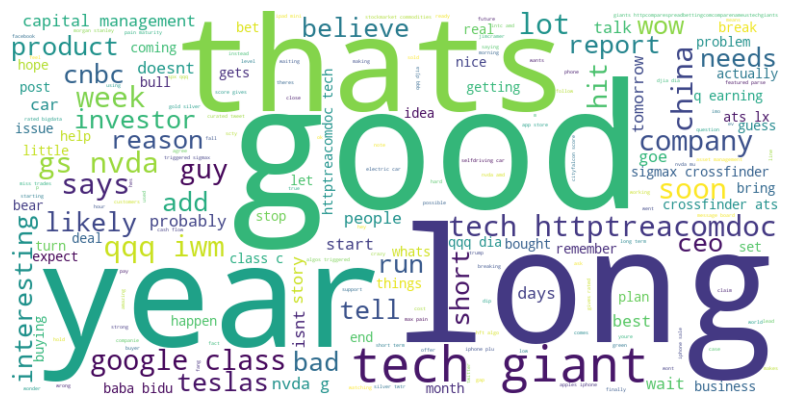

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert the Series to a single string
text_string = " ".join(tweet_data['Text_Cleaned'].dropna())  # Drop NaN values if any

# Generate the word cloud
wordcloud_after_stopword = WordCloud(width=800, height=400, background_color='white').generate(text_string)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_after_stopword, interpolation='bilinear')
plt.axis("off")  # Hide axes
plt.show()


In [19]:
tweet_data.isnull().sum()

tweet_id            0
writer          47273
created_at          0
text                0
comment_num         0
retweet_num         0
like_num            0
Text_Cleaned        0
dtype: int64

In [39]:
empty_count = (tweet_data['Text_Cleaned'].str.strip() == '').sum()
print(f"Empty (non-null) Text_Cleaned rows: {empty_count}")


Empty (non-null) Text_Cleaned rows: 43289


In [40]:
tweet_data = tweet_data[tweet_data['Text_Cleaned'].str.strip() != '']

In [41]:
tweet_data.to_csv('/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Dataset/processed/cleaned_Tweet.csv', index=False)


In [42]:
df = pd.read_csv('/Users/shokoufehnaseri/Library/CloudStorage/OneDrive-Personal/Master-Thesis/Dataset/processed/cleaned_Tweet.csv')


In [43]:
df.isnull().sum()

tweet_id            0
writer          46986
created_at          0
text                0
comment_num         0
retweet_num         0
like_num            0
Text_Cleaned        0
dtype: int64